# Порівняльний аналіз покадрових та послідовних моделей для класифікації відеоданих

## Експерименти на наборі даних Jester

У ноутбуці реалізовано підготовку даних, навчання та оцінювання моделей
CNN + Mean Pooling і CNN-LSTM на наборі даних Jester.

In [ ]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from PIL import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

import importlib
import main_models

importlib.reload(main_models)

from main_models import (
    load_env,
    get_dataset_path,
    prepare_balanced_split,
    print_split_info,
    ClipTrainTransform2,
    ClipEvalTransform,
    JesterDataset,
    CNNMeanPoolingClassifier,
    CNNLSTMClassifier,
    evaluate_custom_videos
)

load_env()

path = get_dataset_path(
    "JESTER_DATASET_PATH",
    "toxicmender/20bn-jester"
)

DATASET_ROOT = Path(path)
NUM_FRAMES = int(os.getenv("NUM_FRAMES", 8))
IMG_SIZE = int(os.getenv("IMG_SIZE", 112))
BATCH_SIZE = int(os.getenv("BATCH_SIZE", 4))
EPOCHS = int(os.getenv("EPOCHS", 10))
LR = float(os.getenv("LR", 1e-4))
SPLITS = ["train", "val", "test"]

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

SELECTED_CLASSES = [
    'Swiping Left',
    'Swiping Right',
    'Swiping Up',
    'Swiping Down',
    'Turning Hand Clockwise',
    'Turning Hand Counterclockwise',
    'Zooming In With Full Hand',
    'Zooming Out With Full Hand'
]

### 1. Дослідження набору даних

In [31]:
print("Path to dataset files:", DATASET_ROOT)
print(os.listdir(path))
print(os.listdir(path + "/Train")[:20])
print(os.listdir(path + "/Train/1000"))


Path to dataset files: C:\Users\Sofiya\.cache\kagglehub\datasets\toxicmender\20bn-jester\versions\3
['Test', 'Test.csv', 'Train', 'Train.csv', 'Validation', 'Validation.csv']
['1', '100', '1000', '10000', '100010', '100011', '100015', '100019', '10002', '10003', '100031', '100034', '100038', '100039', '100040', '100043', '100044', '100047', '10005', '100050']
['00001.jpg', '00002.jpg', '00003.jpg', '00004.jpg', '00005.jpg', '00006.jpg', '00007.jpg', '00008.jpg', '00009.jpg', '00010.jpg', '00011.jpg', '00012.jpg', '00013.jpg', '00014.jpg', '00015.jpg', '00016.jpg', '00017.jpg', '00018.jpg', '00019.jpg', '00020.jpg', '00021.jpg', '00022.jpg', '00023.jpg', '00024.jpg', '00025.jpg', '00026.jpg', '00027.jpg', '00028.jpg', '00029.jpg', '00030.jpg', '00031.jpg', '00032.jpg', '00033.jpg', '00034.jpg', '00035.jpg', '00036.jpg', '00037.jpg']


In [32]:
df_train = pd.read_csv(path + '/Train.csv')
df_train.head()


,video_id,label,frames,label_id,shape,format
0,1,Doing other things,37,0,"(100, 176)",JPEG
1,3,Pushing Two Fingers Away,37,6,"(100, 176)",JPEG
2,6,Drumming Fingers,37,1,"(100, 176)",JPEG
3,11,Sliding Two Fingers Down,37,10,"(100, 176)",JPEG
4,14,Pushing Hand Away,37,5,"(100, 176)",JPEG


In [33]:
df_test = pd.read_csv(path + '/Test.csv')
df_test.head()


,id,label,frames,label_id,shape,format
0,2,NaN,37,NaN,"(100, 176)",JPEG
1,21,NaN,37,NaN,"(100, 176)",JPEG
2,53,NaN,37,NaN,"(100, 176)",JPEG
3,64,NaN,37,NaN,"(100, 132)",JPEG
4,78,NaN,37,NaN,"(100, 176)",JPEG


In [34]:
df_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 50420 entries, 0 to 50419
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   video_id  50420 non-null  int64
 1   label     50420 non-null  str  
 2   frames    50420 non-null  int64
 3   label_id  50420 non-null  int64
 4   shape     50420 non-null  str  
 5   format    50420 non-null  str  
dtypes: int64(3), str(3)
memory usage: 2.3 MB


In [35]:
df_train['label'].value_counts()


label
Doing other things               4374
Pulling Two Fingers In           1859
Zooming Out With Two Fingers     1847
No gesture                       1844
Pushing Two Fingers Away         1843
Thumb Up                         1841
Sliding Two Fingers Down         1832
Zooming Out With Full Hand       1832
Pulling Hand In                  1829
Swiping Down                     1824
Stop Sign                        1821
Drumming Fingers                 1818
Sliding Two Fingers Left         1816
Pushing Hand Away                1812
Thumb Down                       1810
Zooming In With Two Fingers      1801
Zooming In With Full Hand        1799
Shaking Hand                     1789
Rolling Hand Forward             1788
Sliding Two Fingers Right        1780
Sliding Two Fingers Up           1779
Swiping Up                       1768
Swiping Left                     1762
Swiping Right                    1730
Rolling Hand Backward            1715
Turning Hand Counterclockwise    1380
Turnin

In [36]:
df_val = pd.read_csv(path + '/Validation.csv')
df_val.head()


,video_id,label,frames,label_id,shape,format
0,22,Zooming In With Full Hand,37,23,"(100, 176)",JPEG
1,30,Swiping Down,37,15,"(100, 176)",JPEG
2,68,Shaking Hand,37,9,"(100, 176)",JPEG
3,77,Thumb Down,37,19,"(100, 176)",JPEG
4,96,Swiping Right,37,17,"(100, 176)",JPEG


In [37]:
df_val['label'].value_counts()


label
Doing other things               713
Zooming In With Full Hand        262
Zooming Out With Two Fingers     261
Zooming Out With Full Hand       260
Stop Sign                        259
Drumming Fingers                 257
Zooming In With Two Fingers      257
No gesture                       256
Thumb Down                       250
Pulling Hand In                  250
Sliding Two Fingers Down         249
Swiping Down                     248
Swiping Left                     247
Pushing Hand Away                246
Sliding Two Fingers Left         246
Shaking Hand                     245
Sliding Two Fingers Up           244
Rolling Hand Forward             244
Sliding Two Fingers Right        242
Swiping Up                       241
Pushing Two Fingers Away         241
Rolling Hand Backward            239
Thumb Up                         238
Pulling Two Fingers In           233
Swiping Right                    231
Turning Hand Clockwise           196
Turning Hand Counterclockwise   

### 2. Приклади послідовностей кадрів відео різних класів

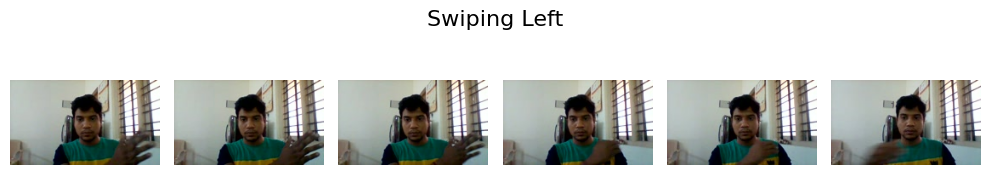

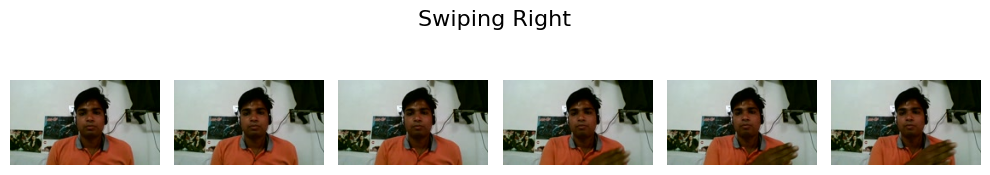

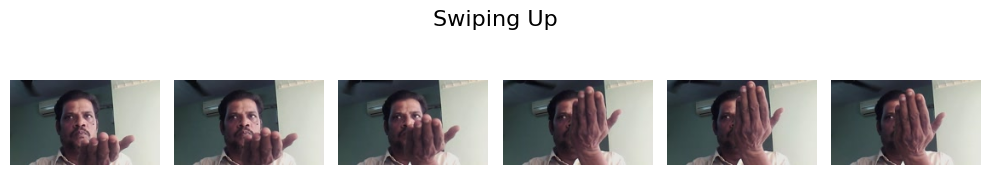

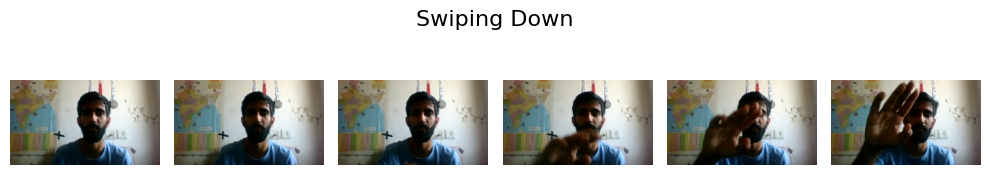

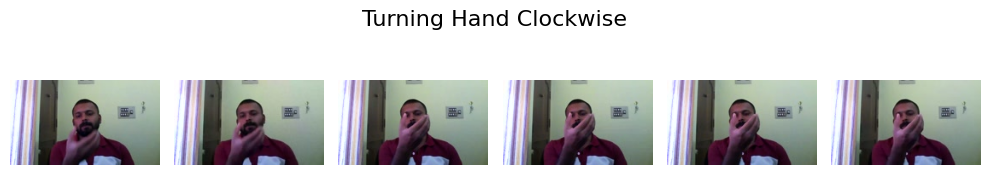

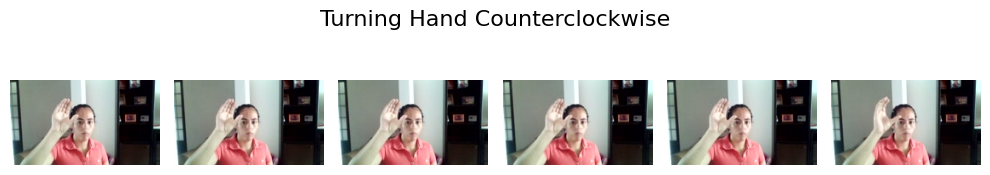

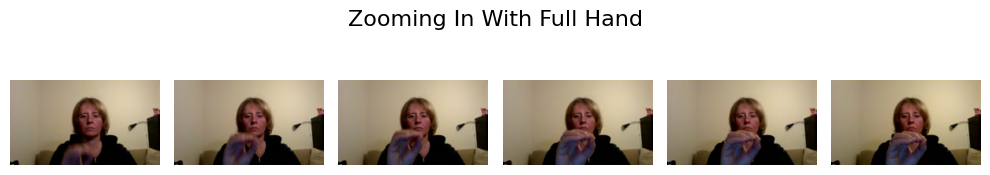

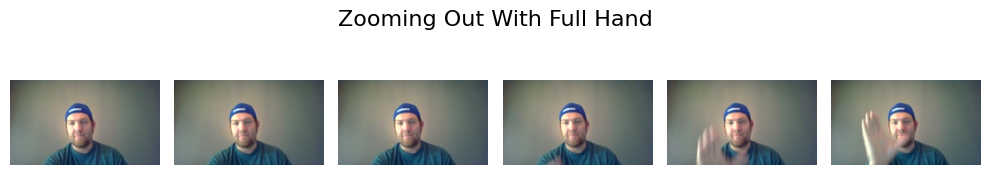

In [59]:
for cls in SELECTED_CLASSES:

    vid = df_train[df_train.label==cls].iloc[9]['video_id']
    folder = os.path.join(path,'Train',str(vid))

    frames = sorted(os.listdir(folder))
    #idx = np.linspace(0,len(frames)-1,16,dtype=int)
    idx = np.linspace(8,15,6,dtype=int)

    plt.figure(figsize=(10,2))
    for i,j in enumerate(idx):
        img = Image.open(os.path.join(folder,frames[j]))

        plt.subplot(1,6,i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(cls, fontsize=16)
    plt.tight_layout()
    plt.show()


### 3. Поділ даних на тренувальну, валідаційну та тестову вибірки у співвідношенні 70/15/15. Створення DataLoader-ів.

In [39]:
df_small, train_df, val_df, test_df, class_to_idx, idx_to_class = prepare_balanced_split(
    df=df_train,
    selected_classes=SELECTED_CLASSES,
    samples_per_class=150,
    test_size=0.3,
)
print_split_info(df_small, train_df, val_df, test_df)

   video_id         label  label_id  new_label_id
0     45697  Swiping Down        15             3
1    141326  Swiping Down        15             3
2     24780  Swiping Down        15             3
3     59981  Swiping Down        15             3
4     75741  Swiping Down        15             3
new_label_id
0    150
1    150
2    150
3    150
4    150
5    150
6    150
7    150
Name: count, dtype: int64
new_label_id
0    105
1    105
2    105
3    105
4    105
5    105
6    105
7    105
Name: count, dtype: int64
new_label_id
0    23
1    23
2    22
3    22
4    22
5    23
6    22
7    23
Name: count, dtype: int64
new_label_id
0    22
1    22
2    23
3    23
4    23
5    22
6    23
7    22
Name: count, dtype: int64
Train_df shape: (840, 7)
Val_df shape: (180, 7)
Test_df shape: (180, 7)


In [40]:
print("Train_df shape: ", train_df.shape)
print("Test_df shape: ", test_df.shape)
print("Val_df shape: ", val_df.shape)


Train_df shape:  (840, 7)
Test_df shape:  (180, 7)
Val_df shape:  (180, 7)


In [41]:
print("Train classes count: ", train_df['label'].value_counts().sort_index())
print("Test classes count: ", test_df['label'].value_counts().sort_index())
print("Val classes count: ", val_df['label'].value_counts().sort_index())


Train classes count:  label
Swiping Down                     105
Swiping Left                     105
Swiping Right                    105
Swiping Up                       105
Turning Hand Clockwise           105
Turning Hand Counterclockwise    105
Zooming In With Full Hand        105
Zooming Out With Full Hand       105
Name: count, dtype: int64
Test classes count:  label
Swiping Down                     23
Swiping Left                     22
Swiping Right                    22
Swiping Up                       23
Turning Hand Clockwise           23
Turning Hand Counterclockwise    22
Zooming In With Full Hand        23
Zooming Out With Full Hand       22
Name: count, dtype: int64
Val classes count:  label
Swiping Down                     22
Swiping Left                     23
Swiping Right                    23
Swiping Up                       22
Turning Hand Clockwise           22
Turning Hand Counterclockwise    23
Zooming In With Full Hand        22
Zooming Out With Full Hand     

In [ ]:
train_dataset = JesterDataset(
    df=train_df,
    root_dir=path,
    split="Train",
    num_frames=NUM_FRAMES,
    transform=ClipTrainTransform2(size=IMG_SIZE),
    mode="train"
)

val_dataset = JesterDataset(
    df=val_df,
    root_dir=path,
    split="Train",
    num_frames=NUM_FRAMES,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

test_dataset = JesterDataset(
    df=test_df,
    root_dir=path,
    split="Train",
    num_frames=NUM_FRAMES,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

### 4. Створення, тренування та оцінка різних моделей

1. Модель CNN+aggregation для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 10, кількість відео для одного класу в train/val/test: 840/180/180, вибір кадрів: рівномірний, з кожного відео взято 8 кадрів.

In [48]:
model_CNN_agg = CNNMeanPoolingClassifier(num_classes=len(class_to_idx), lr=LR)
model_CNN_agg.fit(train_loader, val_loader, epochs=EPOCHS)


Epoch 1/10 | Train loss: 2.2511 | Train acc: 0.1310
Epoch 1/10 | Val loss: 2.3684 | Val acc: 0.1500
Epoch 2/10 | Train loss: 2.1918 | Train acc: 0.1405
Epoch 2/10 | Val loss: 2.1914 | Val acc: 0.1667
Epoch 3/10 | Train loss: 2.1203 | Train acc: 0.1893
Epoch 3/10 | Val loss: 2.1832 | Val acc: 0.1833
Epoch 4/10 | Train loss: 2.1053 | Train acc: 0.1750
Epoch 4/10 | Val loss: 2.2679 | Val acc: 0.1667
Epoch 5/10 | Train loss: 2.0505 | Train acc: 0.2024
Epoch 5/10 | Val loss: 1.9965 | Val acc: 0.2444
Epoch 6/10 | Train loss: 2.0750 | Train acc: 0.1857
Epoch 6/10 | Val loss: 1.9323 | Val acc: 0.2444
Epoch 7/10 | Train loss: 2.0397 | Train acc: 0.1893
Epoch 7/10 | Val loss: 1.9020 | Val acc: 0.2500
Epoch 8/10 | Train loss: 2.0318 | Train acc: 0.1917
Epoch 8/10 | Val loss: 2.0329 | Val acc: 0.2222
Epoch 9/10 | Train loss: 2.0158 | Train acc: 0.2048
Epoch 9/10 | Val loss: 1.8879 | Val acc: 0.2444
Epoch 10/10 | Train loss: 2.0019 | Train acc: 0.2036
Epoch 10/10 | Val loss: 1.9688 | Val acc: 0.283

In [49]:
test_loss_1, test_acc_1 = model_CNN_agg.evaluate(test_loader)

print("Test loss for CNN + mean pooling: ", test_loss_1)
print("Test accuracy for CNN + mean pooling: ", test_acc_1)


Test loss for CNN + mean pooling:  1.879452066289054
Test accuracy for CNN + mean pooling:  0.32222222222222224


In [50]:
total_params_1, trainable_params_1 = model_CNN_agg.count_parameters()

print("Total parameters for CNN + mean pooling:", total_params_1)
print("Trainable parameters for CNN + mean pooling:", trainable_params_1)


Total parameters for CNN + mean pooling: 11180616
Trainable parameters for CNN + mean pooling: 11180616


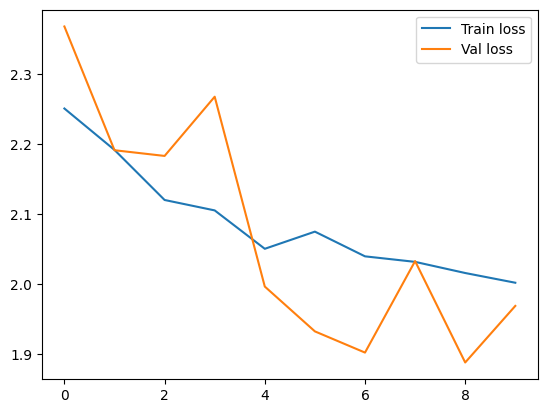

In [51]:
plt.plot(model_CNN_agg.train_losses, label='Train loss')
plt.plot(model_CNN_agg.val_losses, label='Val loss')
plt.legend()
plt.show()


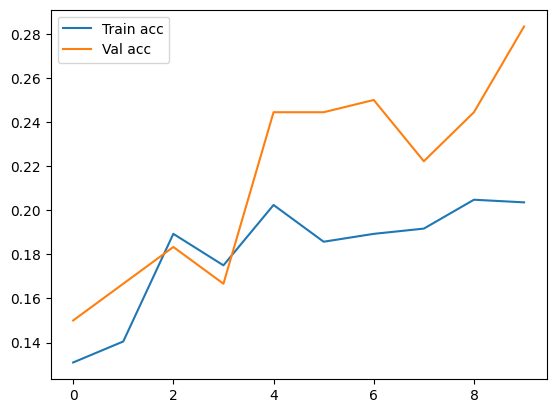

In [52]:
plt.plot(model_CNN_agg.train_accuracies, label='Train acc')
plt.plot(model_CNN_agg.val_accuracies, label='Val acc')
plt.legend()
plt.show()


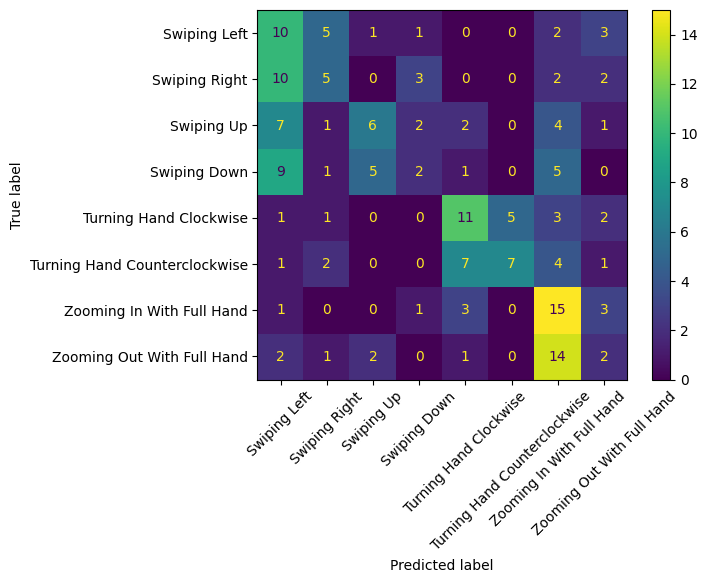

In [53]:
y_true_1, y_pred_1 = model_CNN_agg.get_predictions_and_labels(test_loader)

cm = confusion_matrix(y_true_1, y_pred_1)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_to_idx.keys())
)

disp.plot(
    xticks_rotation=45
)
plt.show()


In [54]:
print(
    classification_report(
        y_true_1,
        y_pred_1,
        target_names=list(class_to_idx.keys())
    )
)


                               precision    recall  f1-score   support

                 Swiping Left       0.24      0.45      0.32        22
                Swiping Right       0.31      0.23      0.26        22
                   Swiping Up       0.43      0.26      0.32        23
                 Swiping Down       0.22      0.09      0.12        23
       Turning Hand Clockwise       0.44      0.48      0.46        23
Turning Hand Counterclockwise       0.58      0.32      0.41        22
    Zooming In With Full Hand       0.31      0.65      0.42        23
   Zooming Out With Full Hand       0.14      0.09      0.11        22

                     accuracy                           0.32       180
                    macro avg       0.33      0.32      0.30       180
                 weighted avg       0.34      0.32      0.30       180



2. Модель CNN-LSTM для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 10, кількість відео для одного класу в train/val/test: 840/180/180, вибір кадрів: рівномірний, з кожного відео взято 8 кадрів.

In [55]:
lstm_model = CNNLSTMClassifier(
    num_classes=len(class_to_idx),
    lr=LR,
    hidden_size=256,
    num_layers=1,
    dropout=0.2
)

lstm_model.fit(train_loader, val_loader, epochs=EPOCHS)


Epoch 1/10 | Train loss: 2.0983 | Train acc: 0.1274
Epoch 1/10 | Val loss: 2.0834 | Val acc: 0.1444
Epoch 2/10 | Train loss: 2.0857 | Train acc: 0.1571
Epoch 2/10 | Val loss: 2.0680 | Val acc: 0.1444
Epoch 3/10 | Train loss: 2.0747 | Train acc: 0.1345
Epoch 3/10 | Val loss: 2.0618 | Val acc: 0.1500
Epoch 4/10 | Train loss: 2.0692 | Train acc: 0.1321
Epoch 4/10 | Val loss: 2.0160 | Val acc: 0.1889
Epoch 5/10 | Train loss: 2.0731 | Train acc: 0.1310
Epoch 5/10 | Val loss: 2.0362 | Val acc: 0.1778
Epoch 6/10 | Train loss: 2.0556 | Train acc: 0.1631
Epoch 6/10 | Val loss: 2.0104 | Val acc: 0.1389
Epoch 7/10 | Train loss: 2.0702 | Train acc: 0.1452
Epoch 7/10 | Val loss: 2.0366 | Val acc: 0.1778
Epoch 8/10 | Train loss: 2.0385 | Train acc: 0.1833
Epoch 8/10 | Val loss: 1.9914 | Val acc: 0.1833
Epoch 9/10 | Train loss: 2.0422 | Train acc: 0.1929
Epoch 9/10 | Val loss: 1.9848 | Val acc: 0.2222
Epoch 10/10 | Train loss: 2.0335 | Train acc: 0.1690
Epoch 10/10 | Val loss: 1.9830 | Val acc: 0.166

In [56]:
test_loss_2, test_acc_2 = lstm_model.evaluate(test_loader)

print("Test loss for CNN-LSTM: ", test_loss_2)
print("Test accuracy for CNN-LSTM: ", test_acc_2)


Test loss for CNN-LSTM:  1.947361832194858
Test accuracy for CNN-LSTM:  0.25


In [57]:
total_params_2, trainable_params_2 = lstm_model.count_parameters()

print("Total parameters for CNN-LSTM:", total_params_2)
print("Trainable parameters for CNN-LSTM:", trainable_params_2)


Total parameters for CNN-LSTM: 11967048
Trainable parameters for CNN-LSTM: 11967048


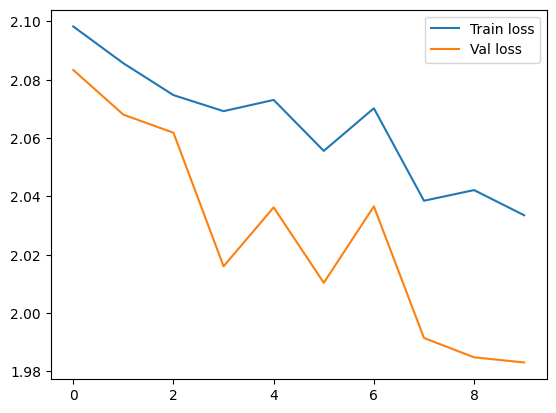

In [58]:
plt.plot(lstm_model.train_losses, label='Train loss')
plt.plot(lstm_model.val_losses, label='Val loss')
plt.legend()
plt.show()


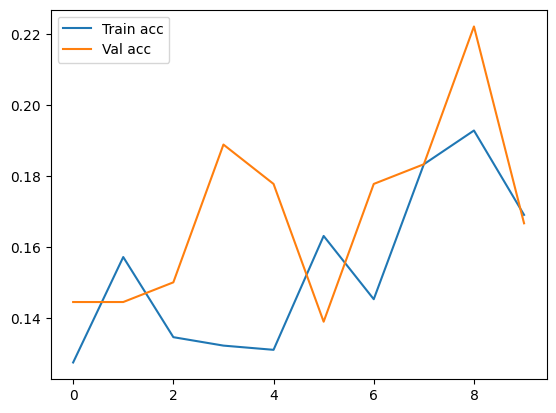

In [59]:
plt.plot(lstm_model.train_accuracies, label='Train acc')
plt.plot(lstm_model.val_accuracies, label='Val acc')
plt.legend()
plt.show()


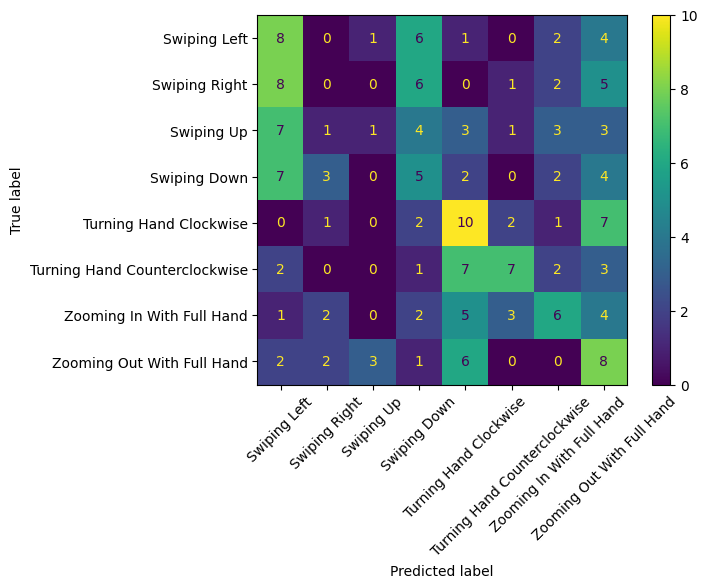

In [60]:
y_true_2, y_pred_2 = lstm_model.get_predictions_and_labels(test_loader)

cm = confusion_matrix(y_true_2, y_pred_2)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_to_idx.keys())
)

disp.plot(
    xticks_rotation=45
)
plt.show()


In [61]:
print(
    classification_report(
        y_true_2,
        y_pred_2,
        target_names=list(class_to_idx.keys())
    )
)


                               precision    recall  f1-score   support

                 Swiping Left       0.23      0.36      0.28        22
                Swiping Right       0.00      0.00      0.00        22
                   Swiping Up       0.20      0.04      0.07        23
                 Swiping Down       0.19      0.22      0.20        23
       Turning Hand Clockwise       0.29      0.43      0.35        23
Turning Hand Counterclockwise       0.50      0.32      0.39        22
    Zooming In With Full Hand       0.33      0.26      0.29        23
   Zooming Out With Full Hand       0.21      0.36      0.27        22

                     accuracy                           0.25       180
                    macro avg       0.24      0.25      0.23       180
                 weighted avg       0.24      0.25      0.23       180



In [44]:
train_dataset2 = JesterDataset(
    df=train_df,
    root_dir=path,
    split="Train",
    num_frames=16,
    transform=ClipTrainTransform2(size=IMG_SIZE),
    mode="train"
)

val_dataset2 = JesterDataset(
    df=val_df,
    root_dir=path,
    split="Train",
    num_frames=16,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

test_dataset2 = JesterDataset(
    df=test_df,
    root_dir=path,
    split="Train",
    num_frames=16,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

train_loader2 = DataLoader(
    train_dataset2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader2 = DataLoader(
    val_dataset2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader2 = DataLoader(
    test_dataset2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


3. Модель CNN+LSTM для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 20, кількість відео для одного класу в train/val/test: 840/180/180, вибір кадрів: центральні, з кожного відео взято 16 кадрів.

In [96]:
lstm_model2 = CNNLSTMClassifier(
    num_classes=len(class_to_idx),
    lr=LR,
    hidden_size=256,
    num_layers=1,
    dropout=0.2
)

lstm_model2.fit(train_loader2, val_loader2, epochs=20)


Epoch 1/20 | Train loss: 2.1000 | Train acc: 0.1321
Epoch 1/20 | Val loss: 2.0266 | Val acc: 0.2278
Epoch 2/20 | Train loss: 2.0812 | Train acc: 0.1417
Epoch 2/20 | Val loss: 2.0250 | Val acc: 0.2000
Epoch 3/20 | Train loss: 2.0702 | Train acc: 0.1619
Epoch 3/20 | Val loss: 1.9746 | Val acc: 0.1889
Epoch 4/20 | Train loss: 2.0467 | Train acc: 0.1774
Epoch 4/20 | Val loss: 1.9834 | Val acc: 0.2278
Epoch 5/20 | Train loss: 2.0377 | Train acc: 0.1679
Epoch 5/20 | Val loss: 1.9600 | Val acc: 0.2111
Epoch 6/20 | Train loss: 2.0120 | Train acc: 0.2060
Epoch 6/20 | Val loss: 1.9614 | Val acc: 0.2111
Epoch 7/20 | Train loss: 2.0306 | Train acc: 0.1917
Epoch 7/20 | Val loss: 1.9624 | Val acc: 0.2000
Epoch 8/20 | Train loss: 2.0256 | Train acc: 0.1917
Epoch 8/20 | Val loss: 2.0238 | Val acc: 0.2222
Epoch 9/20 | Train loss: 2.0180 | Train acc: 0.2036
Epoch 9/20 | Val loss: 1.9811 | Val acc: 0.1944
Epoch 10/20 | Train loss: 2.0012 | Train acc: 0.2250
Epoch 10/20 | Val loss: 1.8872 | Val acc: 0.283

In [97]:
test_loss_3, test_acc_3 = lstm_model2.evaluate(test_loader2)

print("Test loss for CNN-LSTM: ", test_loss_3)
print("Test accuracy for CNN-LSTM: ", test_acc_3)


Test loss for CNN-LSTM:  1.829650546444787
Test accuracy for CNN-LSTM:  0.2777777777777778


In [98]:
total_params_3, trainable_params_3 = lstm_model2.count_parameters()

print("Total parameters for CNN-LSTM:", total_params_3)
print("Trainable parameters for CNN-LSTM:", trainable_params_3)


Total parameters for CNN-LSTM: 11967048
Trainable parameters for CNN-LSTM: 11967048


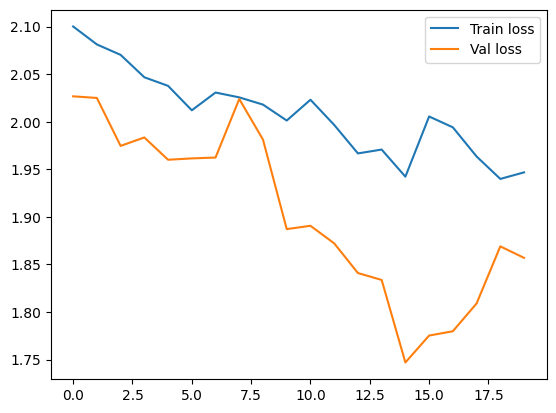

In [99]:
plt.plot(lstm_model2.train_losses, label='Train loss')
plt.plot(lstm_model2.val_losses, label='Val loss')
plt.legend()
plt.show()


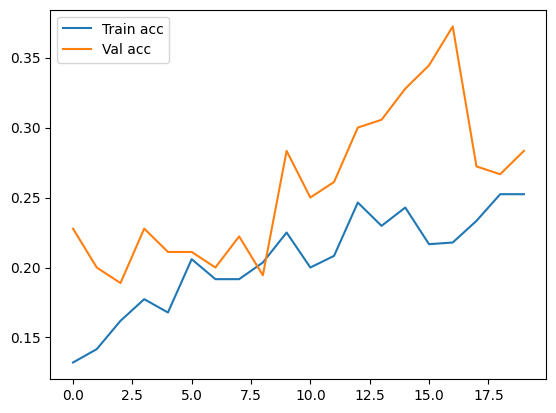

In [100]:
plt.plot(lstm_model2.train_accuracies, label='Train acc')
plt.plot(lstm_model2.val_accuracies, label='Val acc')
plt.legend()
plt.show()


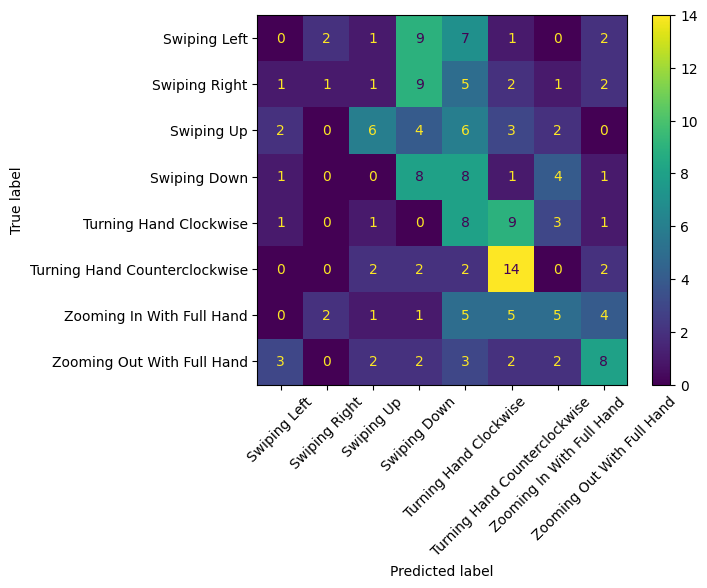

In [101]:
y_true_3, y_pred_3 = lstm_model2.get_predictions_and_labels(test_loader2)

cm = confusion_matrix(y_true_3, y_pred_3)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_to_idx.keys())
)

disp.plot(
    xticks_rotation=45
)
plt.show()


In [102]:
print(
    classification_report(
        y_true_3,
        y_pred_3,
        target_names=list(class_to_idx.keys())
    )
)


                               precision    recall  f1-score   support

                 Swiping Left       0.00      0.00      0.00        22
                Swiping Right       0.20      0.05      0.07        22
                   Swiping Up       0.43      0.26      0.32        23
                 Swiping Down       0.23      0.35      0.28        23
       Turning Hand Clockwise       0.18      0.35      0.24        23
Turning Hand Counterclockwise       0.38      0.64      0.47        22
    Zooming In With Full Hand       0.29      0.22      0.25        23
   Zooming Out With Full Hand       0.40      0.36      0.38        22

                     accuracy                           0.28       180
                    macro avg       0.26      0.28      0.25       180
                 weighted avg       0.26      0.28      0.25       180



Спробуємо для більшої кількості відео на кожен клас, загалом візьмемо 400 відео на клас, тобто для train/val/test: 2560/320/320, збільшимо кількість епох до 25, і збільшимо кількість кадрів до 24.

In [45]:
df_small2, train_df2, val_df2, test_df2, class_to_idx, idx_to_class = prepare_balanced_split(
    df=df_train,
    selected_classes=SELECTED_CLASSES,
    samples_per_class=400,
    test_size=0.2,
)
print_split_info(df_small2, train_df2, val_df2, test_df2)

   video_id         label  label_id  new_label_id
0     45697  Swiping Down        15             3
1    141326  Swiping Down        15             3
2     24780  Swiping Down        15             3
3     59981  Swiping Down        15             3
4     75741  Swiping Down        15             3
new_label_id
0    400
1    400
2    400
3    400
4    400
5    400
6    400
7    400
Name: count, dtype: int64
new_label_id
0    320
1    320
2    320
3    320
4    320
5    320
6    320
7    320
Name: count, dtype: int64
new_label_id
0    40
1    40
2    40
3    40
4    40
5    40
6    40
7    40
Name: count, dtype: int64
new_label_id
0    40
1    40
2    40
3    40
4    40
5    40
6    40
7    40
Name: count, dtype: int64
Train_df shape: (2560, 7)
Val_df shape: (320, 7)
Test_df shape: (320, 7)


In [46]:
train_dataset3 = JesterDataset(
    df=train_df2,
    root_dir=path,
    split="Train",
    num_frames=24,
    transform=ClipTrainTransform2(size=IMG_SIZE),
    mode="train"
)

val_dataset3 = JesterDataset(
    df=val_df2,
    root_dir=path,
    split="Train",
    num_frames=24,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

test_dataset3 = JesterDataset(
    df=test_df2,
    root_dir=path,
    split="Train",
    num_frames=16,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

train_loader3 = DataLoader(
    train_dataset3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader3 = DataLoader(
    val_dataset3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader3 = DataLoader(
    test_dataset3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


4. Модель CNN-LSTM для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 25, кількість відео для одного класу в train/val/test: 2560/320/320, вибір кадрів: центральні, з кожного відео взято 24 кадри.

In [112]:
lstm_model3 = CNNLSTMClassifier(
    num_classes=len(class_to_idx),
    lr=LR,
    hidden_size=256,
    num_layers=1,
    dropout=0.2
)

lstm_model3.fit(train_loader3, val_loader3, epochs=25)


Epoch 1/25 | Train loss: 2.0848 | Train acc: 0.1461
Epoch 1/25 | Val loss: 1.9881 | Val acc: 0.1844
Epoch 2/25 | Train loss: 2.0575 | Train acc: 0.1574
Epoch 2/25 | Val loss: 1.9606 | Val acc: 0.2281
Epoch 3/25 | Train loss: 2.0364 | Train acc: 0.1770
Epoch 3/25 | Val loss: 1.9109 | Val acc: 0.2250
Epoch 4/25 | Train loss: 2.0249 | Train acc: 0.1812
Epoch 4/25 | Val loss: 1.8518 | Val acc: 0.2750
Epoch 5/25 | Train loss: 2.0138 | Train acc: 0.2008
Epoch 5/25 | Val loss: 1.8809 | Val acc: 0.2594
Epoch 6/25 | Train loss: 1.9992 | Train acc: 0.2098
Epoch 6/25 | Val loss: 1.8534 | Val acc: 0.2812
Epoch 7/25 | Train loss: 1.9816 | Train acc: 0.2129
Epoch 7/25 | Val loss: 1.7799 | Val acc: 0.3094
Epoch 8/25 | Train loss: 1.9613 | Train acc: 0.2266
Epoch 8/25 | Val loss: 1.7971 | Val acc: 0.3250
Epoch 9/25 | Train loss: 1.9444 | Train acc: 0.2277
Epoch 9/25 | Val loss: 1.6969 | Val acc: 0.3656
Epoch 10/25 | Train loss: 1.9264 | Train acc: 0.2316
Epoch 10/25 | Val loss: 1.6360 | Val acc: 0.412

KeyboardInterrupt: 

In [113]:
test_loss_4, test_acc_4 = lstm_model3.evaluate(test_loader3)

print("Test loss for CNN-LSTM: ", test_loss_4)
print("Test accuracy for CNN-LSTM: ", test_acc_4)


Test loss for CNN-LSTM:  1.287264436110854
Test accuracy for CNN-LSTM:  0.521875


In [114]:
total_params_4, trainable_params_4 = lstm_model3.count_parameters()

print("Total parameters for CNN-LSTM:", total_params_4)
print("Trainable parameters for CNN-LSTM:", trainable_params_4)


Total parameters for CNN-LSTM: 11967048
Trainable parameters for CNN-LSTM: 11967048


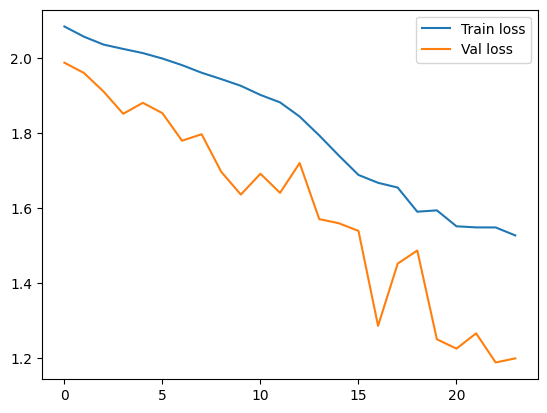

In [115]:
plt.plot(lstm_model3.train_losses, label='Train loss')
plt.plot(lstm_model3.val_losses, label='Val loss')
plt.legend()
plt.show()


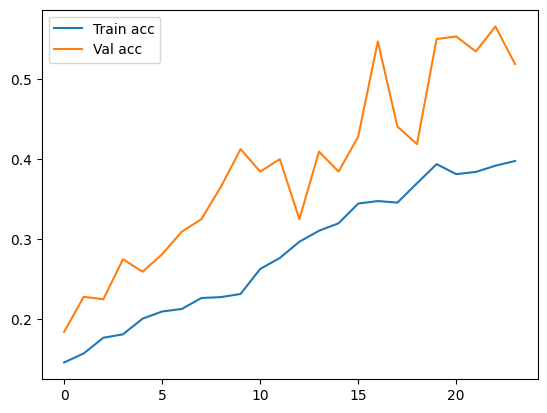

In [116]:
plt.plot(lstm_model3.train_accuracies, label='Train acc')
plt.plot(lstm_model3.val_accuracies, label='Val acc')
plt.legend()
plt.show()


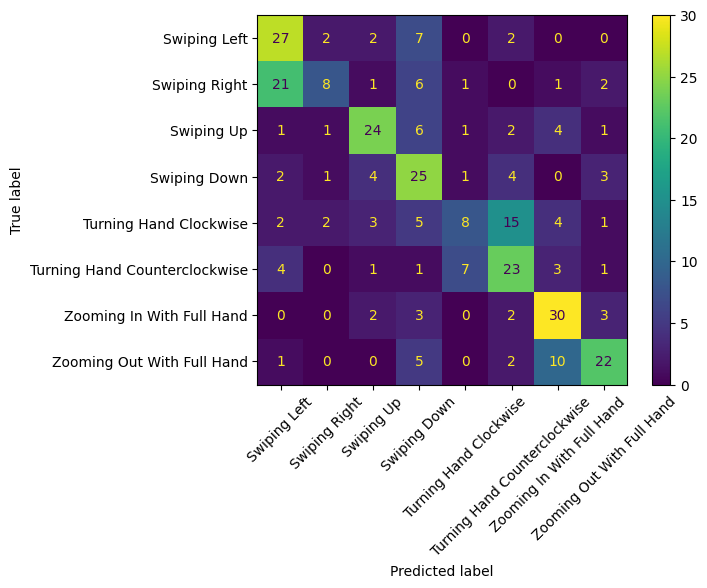

In [117]:
y_true_4, y_pred_4 = lstm_model3.get_predictions_and_labels(test_loader3)

cm = confusion_matrix(y_true_4, y_pred_4)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_to_idx.keys())
)

disp.plot(
    xticks_rotation=45
)
plt.show()


In [118]:
print(
    classification_report(
        y_true_4,
        y_pred_4,
        target_names=list(class_to_idx.keys())
    )
)


                               precision    recall  f1-score   support

                 Swiping Left       0.47      0.68      0.55        40
                Swiping Right       0.57      0.20      0.30        40
                   Swiping Up       0.65      0.60      0.62        40
                 Swiping Down       0.43      0.62      0.51        40
       Turning Hand Clockwise       0.44      0.20      0.28        40
Turning Hand Counterclockwise       0.46      0.57      0.51        40
    Zooming In With Full Hand       0.58      0.75      0.65        40
   Zooming Out With Full Hand       0.67      0.55      0.60        40

                     accuracy                           0.52       320
                    macro avg       0.53      0.52      0.50       320
                 weighted avg       0.53      0.52      0.50       320



5. Модель CNN+aggregation для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 25, кількість відео для одного класу в train/val/test: 2560/320/320, вибір кадрів: центральні, з кожного відео взято 24 кадри.

In [120]:
model_CNN_agg3 = CNNMeanPoolingClassifier(num_classes=len(class_to_idx), lr=LR)
model_CNN_agg3.fit(train_loader3, val_loader3, epochs=24)


Epoch 1/24 | Train loss: 2.1433 | Train acc: 0.1168
Epoch 1/24 | Val loss: 2.1558 | Val acc: 0.1313
Epoch 2/24 | Train loss: 2.1203 | Train acc: 0.1285
Epoch 2/24 | Val loss: 2.1273 | Val acc: 0.1500
Epoch 3/24 | Train loss: 2.1079 | Train acc: 0.1414
Epoch 3/24 | Val loss: 2.1102 | Val acc: 0.1812
Epoch 4/24 | Train loss: 2.1066 | Train acc: 0.1328
Epoch 4/24 | Val loss: 2.1046 | Val acc: 0.1469
Epoch 5/24 | Train loss: 2.1024 | Train acc: 0.1422
Epoch 5/24 | Val loss: 2.0956 | Val acc: 0.1875
Epoch 6/24 | Train loss: 2.1023 | Train acc: 0.1359
Epoch 6/24 | Val loss: 2.0920 | Val acc: 0.2219
Epoch 7/24 | Train loss: 2.0859 | Train acc: 0.1473
Epoch 7/24 | Val loss: 2.0951 | Val acc: 0.1781
Epoch 8/24 | Train loss: 2.0922 | Train acc: 0.1500
Epoch 8/24 | Val loss: 2.0607 | Val acc: 0.1938
Epoch 9/24 | Train loss: 2.0838 | Train acc: 0.1500
Epoch 9/24 | Val loss: 2.0531 | Val acc: 0.1969
Epoch 10/24 | Train loss: 2.0824 | Train acc: 0.1559
Epoch 10/24 | Val loss: 2.0378 | Val acc: 0.228

In [121]:
test_loss_5, test_acc_5 = model_CNN_agg3.evaluate(test_loader3)

print("Test loss for CNN + mean pooling: ", test_loss_5)
print("Test accuracy for CNN + mean pooling: ", test_acc_5)


Test loss for CNN + mean pooling:  1.9809011787176132
Test accuracy for CNN + mean pooling:  0.2


In [122]:
total_params_5, trainable_params_5 = model_CNN_agg3.count_parameters()

print("Total parameters for CNN + mean pooling:", total_params_5)
print("Trainable parameters for CNN + mean pooling:", trainable_params_5)


Total parameters for CNN + mean pooling: 11180616
Trainable parameters for CNN + mean pooling: 4104


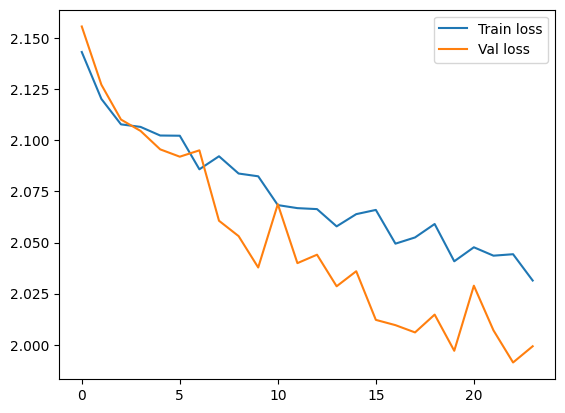

In [123]:
plt.plot(model_CNN_agg3.train_losses, label='Train loss')
plt.plot(model_CNN_agg3.val_losses, label='Val loss')
plt.legend()
plt.show()


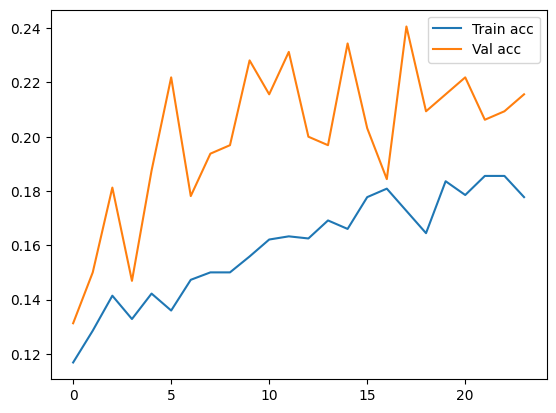

In [124]:
plt.plot(model_CNN_agg3.train_accuracies, label='Train acc')
plt.plot(model_CNN_agg3.val_accuracies, label='Val acc')
plt.legend()
plt.show()


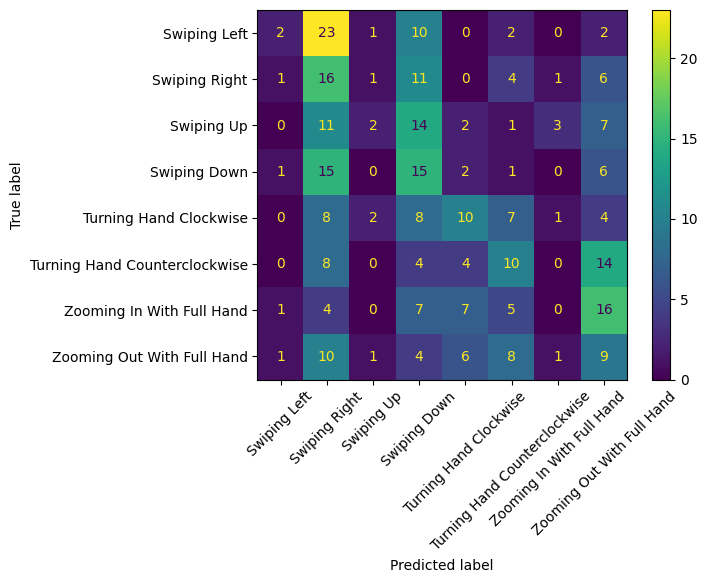

In [125]:
y_true_5, y_pred_5 = model_CNN_agg3.get_predictions_and_labels(test_loader3)

cm = confusion_matrix(y_true_5, y_pred_5)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_to_idx.keys())
)

disp.plot(
    xticks_rotation=45
)
plt.show()


In [126]:
print(
    classification_report(
        y_true_5,
        y_pred_5,
        target_names=list(class_to_idx.keys())
    )
)


                               precision    recall  f1-score   support

                 Swiping Left       0.33      0.05      0.09        40
                Swiping Right       0.17      0.40      0.24        40
                   Swiping Up       0.29      0.05      0.09        40
                 Swiping Down       0.21      0.38      0.27        40
       Turning Hand Clockwise       0.32      0.25      0.28        40
Turning Hand Counterclockwise       0.26      0.25      0.26        40
    Zooming In With Full Hand       0.00      0.00      0.00        40
   Zooming Out With Full Hand       0.14      0.23      0.17        40

                     accuracy                           0.20       320
                    macro avg       0.21      0.20      0.17       320
                 weighted avg       0.21      0.20      0.17       320



6. Модель CNN+agg для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 10, кількість відео для одного класу в train/val/test: 840/180/180, вибір кадрів: центральні, з кожного відео взято 16 кадрів.

In [ ]:
train_dataset4 = JesterDataset(
    df=train_df,
    root_dir=path,
    split="Train",
    num_frames=16,
    transform=ClipTrainTransform2(size=IMG_SIZE),
    mode="train"
)

val_dataset4 = JesterDataset(
    df=val_df,
    root_dir=path,
    split="Train",
    num_frames=16,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

test_dataset4 = JesterDataset(
    df=test_df,
    root_dir=path,
    split="Train",
    num_frames=16,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

train_loader4 = DataLoader(
    train_dataset4,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader4 = DataLoader(
    val_dataset4,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader4 = DataLoader(
    test_dataset4,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


In [142]:
model_CNN_agg4 = CNNMeanPoolingClassifier(num_classes=len(class_to_idx), lr=LR)
model_CNN_agg4.fit(train_loader4, val_loader4, epochs=EPOCHS)


Epoch 1/10 | Train loss: 2.1925 | Train acc: 0.1464
Epoch 1/10 | Val loss: 2.3519 | Val acc: 0.1611
Epoch 2/10 | Train loss: 2.1252 | Train acc: 0.1714
Epoch 2/10 | Val loss: 2.1055 | Val acc: 0.2333
Epoch 3/10 | Train loss: 2.0987 | Train acc: 0.1869
Epoch 3/10 | Val loss: 1.8627 | Val acc: 0.3111
Epoch 4/10 | Train loss: 2.0355 | Train acc: 0.2060
Epoch 4/10 | Val loss: 1.8157 | Val acc: 0.3111
Epoch 5/10 | Train loss: 2.0232 | Train acc: 0.2238
Epoch 5/10 | Val loss: 1.9484 | Val acc: 0.2611
Epoch 6/10 | Train loss: 1.9636 | Train acc: 0.2488
Epoch 6/10 | Val loss: 1.9372 | Val acc: 0.3389
Epoch 7/10 | Train loss: 1.9661 | Train acc: 0.2333
Epoch 7/10 | Val loss: 2.0499 | Val acc: 0.3111
Epoch 8/10 | Train loss: 1.9424 | Train acc: 0.2571
Epoch 8/10 | Val loss: 1.6406 | Val acc: 0.3833
Epoch 9/10 | Train loss: 1.9329 | Train acc: 0.2571
Epoch 9/10 | Val loss: 1.8385 | Val acc: 0.3444
Epoch 10/10 | Train loss: 1.8914 | Train acc: 0.2726
Epoch 10/10 | Val loss: 1.7654 | Val acc: 0.405

In [144]:
test_loss_6, test_acc_6 = model_CNN_agg4.evaluate(test_loader4)

print("Test loss for CNN + mean pooling: ", test_loss_6)
print("Test accuracy for CNN + mean pooling: ", test_acc_6)


Test loss for CNN + mean pooling:  2.076403930452135
Test accuracy for CNN + mean pooling:  0.3


In [145]:
total_params_6, trainable_params_6 = model_CNN_agg4.count_parameters()

print("Total parameters for CNN + mean pooling:", total_params_6)
print("Trainable parameters for CNN + mean pooling:", trainable_params_6)


Total parameters for CNN + mean pooling: 11180616
Trainable parameters for CNN + mean pooling: 11180616


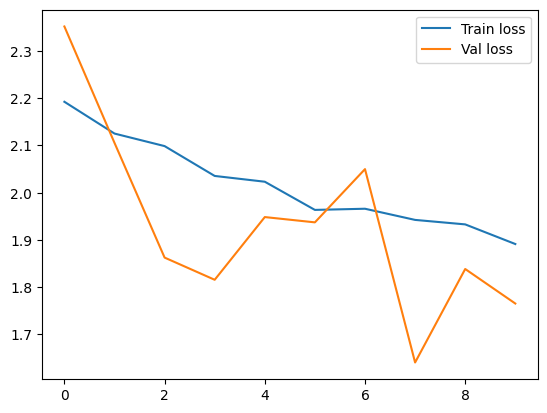

In [146]:
plt.plot(model_CNN_agg4.train_losses, label='Train loss')
plt.plot(model_CNN_agg4.val_losses, label='Val loss')
plt.legend()
plt.show()


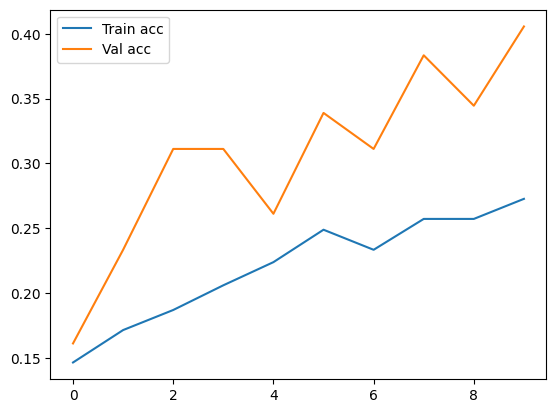

In [147]:
plt.plot(model_CNN_agg4.train_accuracies, label='Train acc')
plt.plot(model_CNN_agg4.val_accuracies, label='Val acc')
plt.legend()
plt.show()


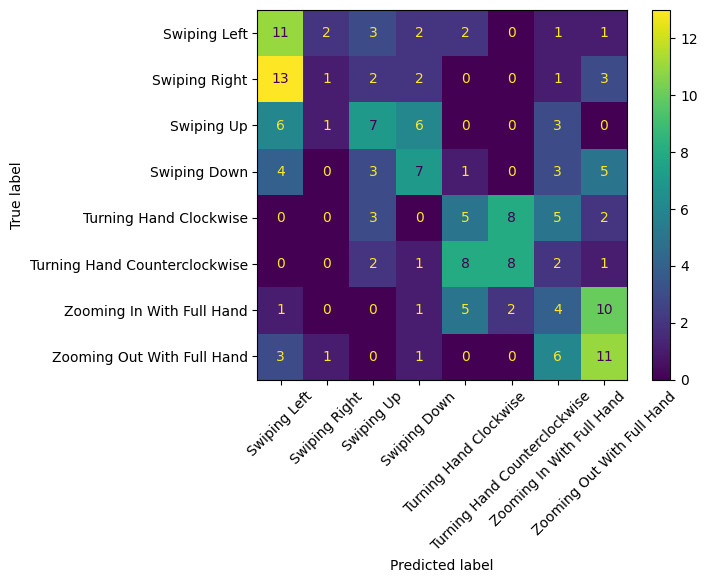

In [148]:
y_true_6, y_pred_6 = model_CNN_agg4.get_predictions_and_labels(test_loader4)

cm = confusion_matrix(y_true_6, y_pred_6)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_to_idx.keys())
)

disp.plot(
    xticks_rotation=45
)
plt.show()


In [149]:
print(
    classification_report(
        y_true_6,
        y_pred_6,
        target_names=list(class_to_idx.keys())
    )
)


                               precision    recall  f1-score   support

                 Swiping Left       0.29      0.50      0.37        22
                Swiping Right       0.20      0.05      0.07        22
                   Swiping Up       0.35      0.30      0.33        23
                 Swiping Down       0.35      0.30      0.33        23
       Turning Hand Clockwise       0.24      0.22      0.23        23
Turning Hand Counterclockwise       0.44      0.36      0.40        22
    Zooming In With Full Hand       0.16      0.17      0.17        23
   Zooming Out With Full Hand       0.33      0.50      0.40        22

                     accuracy                           0.30       180
                    macro avg       0.30      0.30      0.29       180
                 weighted avg       0.30      0.30      0.29       180



7. Модель CNN-LSTM для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 10, кількість відео для одного класу в train/val/test: 840/180/180, вибір кадрів: центральні, з кожного відео взято 16 кадрів.

In [150]:
lstm_model4 = CNNLSTMClassifier(
    num_classes=len(class_to_idx),
    lr=LR,
    hidden_size=256,
    num_layers=1,
    dropout=0.2
)

lstm_model4.fit(train_loader4, val_loader4, epochs=EPOCHS)


Epoch 1/10 | Train loss: 2.0992 | Train acc: 0.1381
Epoch 1/10 | Val loss: 2.0464 | Val acc: 0.1889
Epoch 2/10 | Train loss: 2.0716 | Train acc: 0.1500
Epoch 2/10 | Val loss: 2.0140 | Val acc: 0.1944
Epoch 3/10 | Train loss: 2.0692 | Train acc: 0.1464
Epoch 3/10 | Val loss: 1.9839 | Val acc: 0.2333
Epoch 4/10 | Train loss: 2.0516 | Train acc: 0.1810
Epoch 4/10 | Val loss: 1.9125 | Val acc: 0.3167
Epoch 5/10 | Train loss: 2.0463 | Train acc: 0.1869
Epoch 5/10 | Val loss: 1.8763 | Val acc: 0.2889
Epoch 6/10 | Train loss: 2.0119 | Train acc: 0.1845
Epoch 6/10 | Val loss: 1.9124 | Val acc: 0.2167
Epoch 7/10 | Train loss: 2.0039 | Train acc: 0.2060
Epoch 7/10 | Val loss: 1.8545 | Val acc: 0.3056
Epoch 8/10 | Train loss: 2.0227 | Train acc: 0.1917
Epoch 8/10 | Val loss: 1.8920 | Val acc: 0.2778
Epoch 9/10 | Train loss: 1.9734 | Train acc: 0.2143
Epoch 9/10 | Val loss: 1.9705 | Val acc: 0.2722
Epoch 10/10 | Train loss: 1.9528 | Train acc: 0.2548
Epoch 10/10 | Val loss: 1.8254 | Val acc: 0.338

In [151]:
test_loss_7, test_acc_7 = lstm_model4.evaluate(test_loader4)

print("Test loss for CNN-LSTM: ", test_loss_7)
print("Test accuracy for CNN-LSTM: ", test_acc_7)


Test loss for CNN-LSTM:  1.7971645302242703
Test accuracy for CNN-LSTM:  0.35


In [152]:
total_params_7, trainable_params_7 = lstm_model4.count_parameters()

print("Total parameters for CNN + mean pooling:", total_params_7)
print("Trainable parameters for CNN + mean pooling:", trainable_params_7)


Total parameters for CNN + mean pooling: 11967048
Trainable parameters for CNN + mean pooling: 11967048


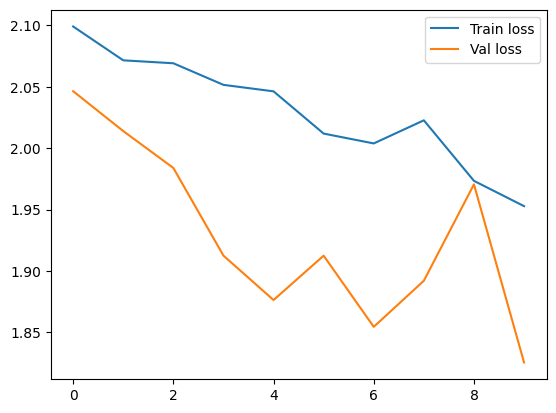

In [153]:
plt.plot(lstm_model4.train_losses, label='Train loss')
plt.plot(lstm_model4.val_losses, label='Val loss')
plt.legend()
plt.show()


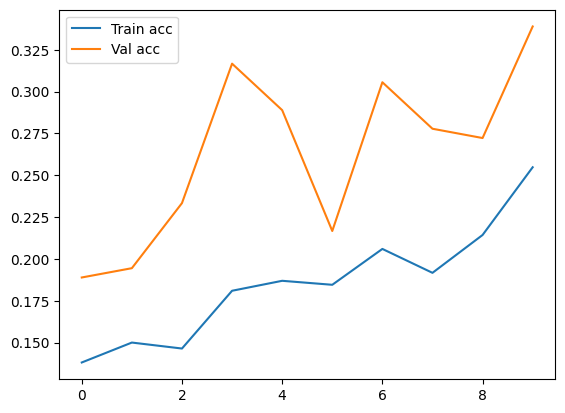

In [154]:
plt.plot(lstm_model4.train_accuracies, label='Train acc')
plt.plot(lstm_model4.val_accuracies, label='Val acc')
plt.legend()
plt.show()


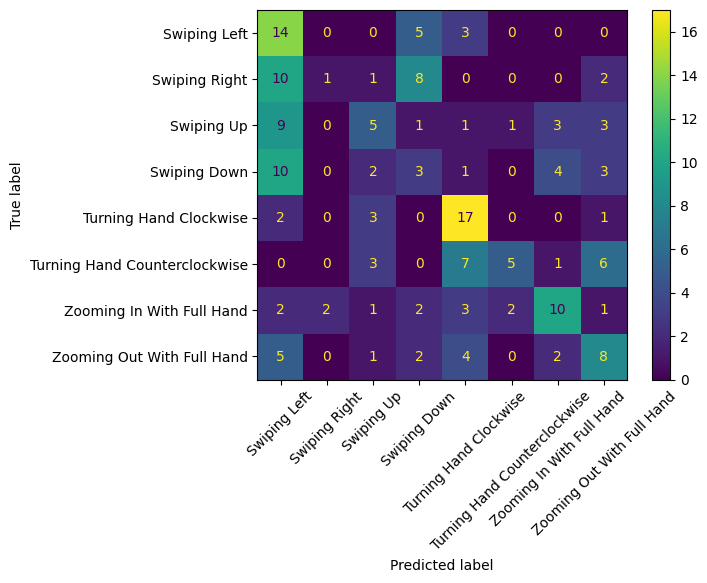

In [155]:
y_true_7, y_pred_7 = lstm_model4.get_predictions_and_labels(test_loader4)

cm = confusion_matrix(y_true_7, y_pred_7)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(class_to_idx.keys())
)

disp.plot(
    xticks_rotation=45
)
plt.show()


In [156]:
print(
    classification_report(
        y_true_7,
        y_pred_7,
        target_names=list(class_to_idx.keys())
    )
)


                               precision    recall  f1-score   support

                 Swiping Left       0.27      0.64      0.38        22
                Swiping Right       0.33      0.05      0.08        22
                   Swiping Up       0.31      0.22      0.26        23
                 Swiping Down       0.14      0.13      0.14        23
       Turning Hand Clockwise       0.47      0.74      0.58        23
Turning Hand Counterclockwise       0.62      0.23      0.33        22
    Zooming In With Full Hand       0.50      0.43      0.47        23
   Zooming Out With Full Hand       0.33      0.36      0.35        22

                     accuracy                           0.35       180
                    macro avg       0.37      0.35      0.32       180
                 weighted avg       0.37      0.35      0.32       180



Спробуємо датасет з 250 відео на клас, 24 кадри і 25 епох.

In [52]:
df_small3, train_df3, val_df3, test_df3, class_to_idx, idx_to_class = prepare_balanced_split(
    df=df_train,
    selected_classes=SELECTED_CLASSES,
    samples_per_class=250,
    test_size=0.2,
)
print_split_info(df_small3, train_df3, val_df3, test_df3)

   video_id         label  label_id  new_label_id
0     45697  Swiping Down        15             3
1    141326  Swiping Down        15             3
2     24780  Swiping Down        15             3
3     59981  Swiping Down        15             3
4     75741  Swiping Down        15             3
new_label_id
0    250
1    250
2    250
3    250
4    250
5    250
6    250
7    250
Name: count, dtype: int64
new_label_id
0    200
1    200
2    200
3    200
4    200
5    200
6    200
7    200
Name: count, dtype: int64
new_label_id
0    25
1    25
2    25
3    25
4    25
5    25
6    25
7    25
Name: count, dtype: int64
new_label_id
0    25
1    25
2    25
3    25
4    25
5    25
6    25
7    25
Name: count, dtype: int64
Train_df shape: (1600, 7)
Val_df shape: (200, 7)
Test_df shape: (200, 7)


In [54]:
train_dataset5 = JesterDataset(
    df=train_df3,
    root_dir=path,
    split="Train",
    num_frames=24,
    transform=ClipTrainTransform2(size=IMG_SIZE),
    mode="train"
)

val_dataset5 = JesterDataset(
    df=val_df3,
    root_dir=path,
    split="Train",
    num_frames=24,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

test_dataset5 = JesterDataset(
    df=test_df3,
    root_dir=path,
    split="Train",
    num_frames=24,
    transform=ClipEvalTransform(size=IMG_SIZE),
    mode="eval"
)

train_loader5 = DataLoader(
    train_dataset5,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader5 = DataLoader(
    val_dataset5,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader5 = DataLoader(
    test_dataset5,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)


8. Модель CNN-LSTM для Jester dataset, 8 класів: 'Swiping Left', 'Swiping Right', 'Swiping Up', 'Swiping Down', 'Turning Hand Clockwise', 'Turning Hand Counterclockwise', 'Zooming In With Full Hand', 'Zooming Out With Full Hand', розмір зображень 112*112, batch_size = 4, epochs = 24, кількість відео для одного класу в train/val/test: 1600/200/200, вибір кадрів: центральні, з кожного відео взято 24 кадрів.

In [56]:
lstm_model5 = CNNLSTMClassifier(
    num_classes=len(class_to_idx),
    lr=1e-5,
    hidden_size=256,
    num_layers=1,
    dropout=0.2
)

lstm_model5.fit(train_loader5, val_loader5, epochs=24)

Epoch 1/24 | Train loss: 2.0847 | Train acc: 0.1269
Epoch 1/24 | Val loss: 2.0427 | Val acc: 0.1850
Epoch 2/24 | Train loss: 2.0745 | Train acc: 0.1462
Epoch 2/24 | Val loss: 2.0298 | Val acc: 0.1800
Epoch 3/24 | Train loss: 2.0648 | Train acc: 0.1694
Epoch 3/24 | Val loss: 2.0088 | Val acc: 0.2500
Epoch 4/24 | Train loss: 2.0579 | Train acc: 0.1625
Epoch 4/24 | Val loss: 1.9862 | Val acc: 0.2600
Epoch 5/24 | Train loss: 2.0434 | Train acc: 0.1831
Epoch 5/24 | Val loss: 1.9529 | Val acc: 0.3000
Epoch 6/24 | Train loss: 2.0323 | Train acc: 0.1956
Epoch 6/24 | Val loss: 1.9200 | Val acc: 0.2750
Epoch 7/24 | Train loss: 2.0155 | Train acc: 0.2200
Epoch 7/24 | Val loss: 1.8894 | Val acc: 0.3250
Epoch 8/24 | Train loss: 1.9986 | Train acc: 0.2206
Epoch 8/24 | Val loss: 1.8464 | Val acc: 0.3650
Epoch 9/24 | Train loss: 1.9974 | Train acc: 0.2281
Epoch 9/24 | Val loss: 1.7939 | Val acc: 0.3550
Epoch 10/24 | Train loss: 1.9714 | Train acc: 0.2369
Epoch 10/24 | Val loss: 1.7753 | Val acc: 0.355

In [61]:
lstm_model5_load = CNNLSTMClassifier(
    num_classes=len(class_to_idx),
    lr=1e-5,
    hidden_size=256,
    num_layers=1,
    dropout=0.2,
    checkpoint_path="best_lstm_model_finetuned.pth"
)

lstm_model5_load.load_state_dict(
    torch.load("best_lstm_model.pth", map_location="cpu")
)

lstm_model5_load.fit(
    train_loader5,
    val_loader5,
    epochs=6
)

Epoch 1/6 | Train loss: 1.8226 | Train acc: 0.3137
Epoch 1/6 | Val loss: 1.4279 | Val acc: 0.5200
Epoch 2/6 | Train loss: 1.7637 | Train acc: 0.3394
Epoch 2/6 | Val loss: 1.4396 | Val acc: 0.4950
Epoch 3/6 | Train loss: 1.7933 | Train acc: 0.3356
Epoch 3/6 | Val loss: 1.4087 | Val acc: 0.5350
Epoch 4/6 | Train loss: 1.7818 | Train acc: 0.3181
Epoch 4/6 | Val loss: 1.4214 | Val acc: 0.5100
Epoch 5/6 | Train loss: 1.7491 | Train acc: 0.3463
Epoch 5/6 | Val loss: 1.4159 | Val acc: 0.5200
Epoch 6/6 | Train loss: 1.7436 | Train acc: 0.3500
Epoch 6/6 | Val loss: 1.3786 | Val acc: 0.5700


In [ ]:
test_loss_8, test_acc_8 = lstm_model5_load.evaluate(test_loader5)

print("Test loss for CNN-LSTM: ", test_loss_8)
print("Test accuracy for CNN-LSTM: ", test_acc_8)

Test loss for CNN-LSTM:  1.4078956615924836
Test accuracy for CNN-LSTM:  0.48


### 5. Завантаження та обробка власних даних. Апробація 8-ої моделі на власних даних.

In [67]:
transform = ClipEvalTransform(size=112)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model5_load.to(device)
lstm_model5_load.eval()


results_df = evaluate_custom_videos(
    root_dir=r"c:\Users\Sofiya\Documents\дипломна\new_data",
    model=lstm_model5_load,
    transform=transform,
    num_frames=24,
    idx_to_class=idx_to_class,
    selected_classes=SELECTED_CLASSES,
    device=device,
)

results_df

,video,true_class,predicted_class,confidence,correct
0,video_01.mp4,Swiping Left,Swiping Down,0.223244,False
1,video_02.mp4,Swiping Left,Swiping Left,0.258698,True
2,video_03.mp4,Swiping Left,Swiping Up,0.197546,False
3,video_04.mp4,Swiping Left,Zooming In With Full Hand,0.224379,False
4,video_05.mp4,Swiping Left,Swiping Down,0.382679,False
...,...,...,...,...,...
59,video_04.mp4,Zooming Out With Full Hand,Zooming In With Full Hand,0.178091,False
60,video_05.mp4,Zooming Out With Full Hand,Zooming Out With Full Hand,0.527300,True
61,video_06.mp4,Zooming Out With Full Hand,Zooming Out With Full Hand,0.841700,True
62,video_07.mp4,Zooming Out With Full Hand,Zooming Out With Full Hand,0.412986,True


In [69]:
custom_accuracy = results_df["correct"].mean()
print(f"Accuracy on custom videos: {custom_accuracy:.4f}")
print(results_df["correct"].value_counts())

Accuracy on custom videos: 0.3750
correct
False    40
True     24
Name: count, dtype: int64


In [70]:
class_accuracy = (
    results_df
    .groupby("true_class")["correct"]
    .mean()
    .sort_values(ascending=False)
)
print(class_accuracy)

true_class
Zooming In With Full Hand        0.750
Swiping Down                     0.625
Zooming Out With Full Hand       0.500
Swiping Up                       0.500
Turning Hand Counterclockwise    0.250
Turning Hand Clockwise           0.250
Swiping Left                     0.125
Swiping Right                    0.000
Name: correct, dtype: float64


In [88]:
cr = classification_report(
        results_df["true_class"],
        results_df["predicted_class"],
        labels=SELECTED_CLASSES,
        zero_division=0,
    )
print(cr)

                               precision    recall  f1-score   support

                 Swiping Left       0.14      0.12      0.13         8
                Swiping Right       0.00      0.00      0.00         8
                   Swiping Up       0.44      0.50      0.47         8
                 Swiping Down       0.23      0.62      0.33         8
       Turning Hand Clockwise       1.00      0.25      0.40         8
Turning Hand Counterclockwise       1.00      0.25      0.40         8
    Zooming In With Full Hand       0.35      0.75      0.48         8
   Zooming Out With Full Hand       1.00      0.50      0.67         8

                     accuracy                           0.38        64
                    macro avg       0.52      0.38      0.36        64
                 weighted avg       0.52      0.38      0.36        64



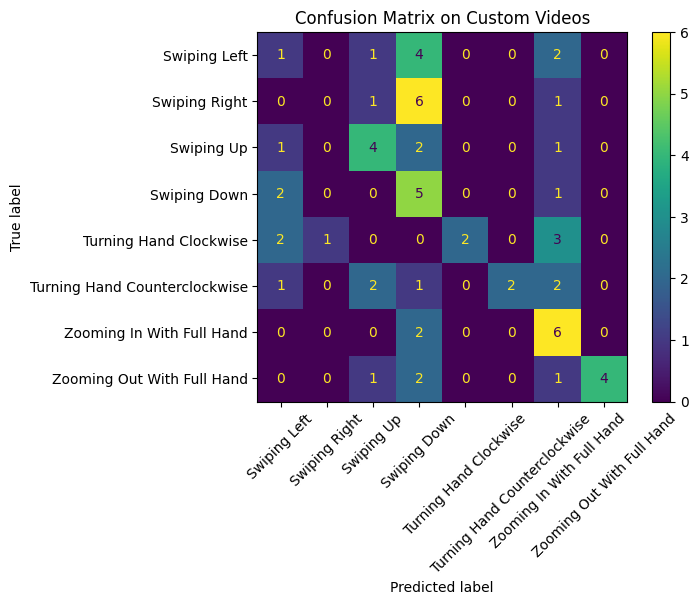

In [72]:
cm = confusion_matrix(
    results_df["true_class"],
    results_df["predicted_class"],
    labels=SELECTED_CLASSES,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=SELECTED_CLASSES,
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix on Custom Videos")
plt.show()